##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells.

# EXAM03: Data Science Group Assignment - Iteration 3

**Group name:** [Enter Group Number]

**Student names & numbers:**
* Scott Mulder - 101232
* Sidney Felius - 101168
* Valentijn van Grunsven - kansloos

---

## 0. Iteration setup

**Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (mean_absolute_error, mean_squared_error, 
                             r2_score, accuracy_score, confusion_matrix)

**Load & Merge dataset(s)**

In [2]:

df_iter1 = pd.read_csv('data/ships_inventory_iter1.csv')
df_iter2 = pd.read_csv('data/ship_inspections_iter2.csv')
df_iter3 = pd.read_csv('data/ship_performance_logs_iter3.csv')

# Merge the datasets on Ship_ID
df_merged = df_iter1.merge(df_iter2, on='Ship_ID', how='outer').merge(df_iter3, on='Ship_ID', how='outer')

print(f"Iteration 1 dataset shape: {df_iter1.shape}")
print(f"Iteration 2 dataset shape: {df_iter2.shape}")
print(f"Iteration 3 dataset shape: {df_iter3.shape}")
print(f"Merged dataset shape: {df_merged.shape}")
print(f"\nMerged dataset columns:\n{df_merged.columns.tolist()}")

Iteration 1 dataset shape: (368814, 5)
Iteration 2 dataset shape: (368315, 5)
Iteration 3 dataset shape: (361069, 3)
Merged dataset shape: (368815, 11)

Merged dataset columns:
['Ship_ID', 'Galactic_Credits', 'Model_Cycle', 'Ship_Manufacturer', 'Sector', 'Hull_Integrity', 'Reactor_Power', 'Propulsion_Type', 'Ship_Class', 'Lightyears_Traveled', 'Registration_Status']


---

## 1. Business Understanding

**Situation description**

*Describe the final problem. Why is Nebula Brokerage moving from the simple models (iterations 1 and 2) to a machine learning approach?*

**Business objective(s)**

*Justify why an AI-driven pipeline (predicting both Galactic Credits and Condition) adds business value.*

**Data mining goal(s)**

*Explain the two modeling tasks for this iteration.*

**Success criteria**

*Determine the success criteria.*

---

## 2. Data Understanding

**Data exploration (New Features)**

*Show the summary statistics for the newly merged data. Focus your description on the new variables: Lightyears_Traveled and Registration_Status.*

In [3]:
print("First five rows of the dataset:")
display(df_merged.head(10))

print("Dataset Information:")
df_merged.info()

print("Description of the dataset:")
df_merged.describe(include=['object'])

First five rows of the dataset:


,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class,Lightyears_Traveled,Registration_Status
0,7301583321,18997.0,7513.0,Droid Works,New Yavin,Operational,80.0,Ion Drive,Explorer,82.492905,Stolen
1,7301583353,51997.0,7517.0,Corellian Eng.,New Yavin,Pristine,100.0,Hyperdrive,Hauler,35.505393,Imperial Certified
2,7301583380,28997.0,7516.0,Kuat Drive Yards,New Yavin,Operational,100.0,Plasma Thruster,Hauler,62.234718,Refurbished
3,7301583995,24900.0,7512.0,Kuat Drive Yards,Neimoidia purse,Operational,60.0,Plasma Thruster,Shuttle,103.430095,Refurbished
4,7301584015,24900.0,7512.0,Kuat Drive Yards,Coruscant Core,Operational,60.0,Plasma Thruster,Shuttle,105.701466,Refurbished
5,7301584024,24900.0,7512.0,Kuat DY,Nevarro Trade Route,Operational,NaN,NaN,Shuttle,91.334321,Refurbished
6,7301584031,1000.0,7503.0,Corellian Engineering,Calodan Expanse,Critical,60.0,Hyperdrive,Shuttle,247.419906,Smuggler Logic
7,7301584709,11750.0,7513.0,Hondo Systems,Vardos City,Operational,40.0,Solar Sail,Shuttle,53.518861,Refurbished
8,7301585649,2995.0,7458.0,Mercurian Benz,Onderon Wilds,Critical,40.0,Nuclear Pulse,Shuttle,1.420660,Imperial Certified
9,7301586610,7000.0,7510.0,Galactic Motors,Tatooine Binary System,Operational,NaN,Ion Drive,Shuttle,97.577147,Stolen


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 368815 entries, 0 to 368814
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Ship_ID              368815 non-null  int64  
 1   Galactic_Credits     368814 non-null  float64
 2   Model_Cycle          361408 non-null  float64
 3   Ship_Manufacturer    368814 non-null  str    
 4   Sector               368814 non-null  str    
 5   Hull_Integrity       368815 non-null  str    
 6   Reactor_Power        339346 non-null  float64
 7   Propulsion_Type      312109 non-null  str    
 8   Ship_Class           368815 non-null  str    
 9   Lightyears_Traveled  361561 non-null  float64
 10  Registration_Status  361561 non-null  str    
dtypes: float64(4), int64(1), str(6)
memory usage: 31.0 MB
Description of the dataset:


C:\Users\sidne\AppData\Local\Temp\ipykernel_35364\1716049467.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_merged.describe(include=['object'])


,Ship_Manufacturer,Sector,Hull_Integrity,Propulsion_Type,Ship_Class,Registration_Status
count,368814,368814,368815,312109,368815,361561
unique,28,51,3,8,8,6
top,Independent Shipwrights,Calodan Expanse,Operational,Ion Drive,Shuttle,Imperial Certified
freq,94444,42150,141464,177608,125887,175553



### Inzichten dataset
Er is geen duidelijke correlatie tussen prijs en afgelegde afstand.  
Sommige goedkope schepen hebben veel gereisd, terwijl dure schepen juist minder afstand hebben afgelegd.  
afstand heeft dus weinig invloed op de prijs. Grotere schepen (zoals Haulers) hebben vaak een hogere power. Er zijn missende waarden in sommige kolommen en er zijn niet goeie namen van fabrikanten, er is een sterke relatie tussen conditie en prijs  

### Hull_Integrity vs. prijs  
  Betere conditie leidt meestal tot een hogere prijs.  
  Slechte conditie leidt meestal tot een lagere prijs.  



**Visualizations and patterns**
*Create visualizations to discover the impact of the new features.

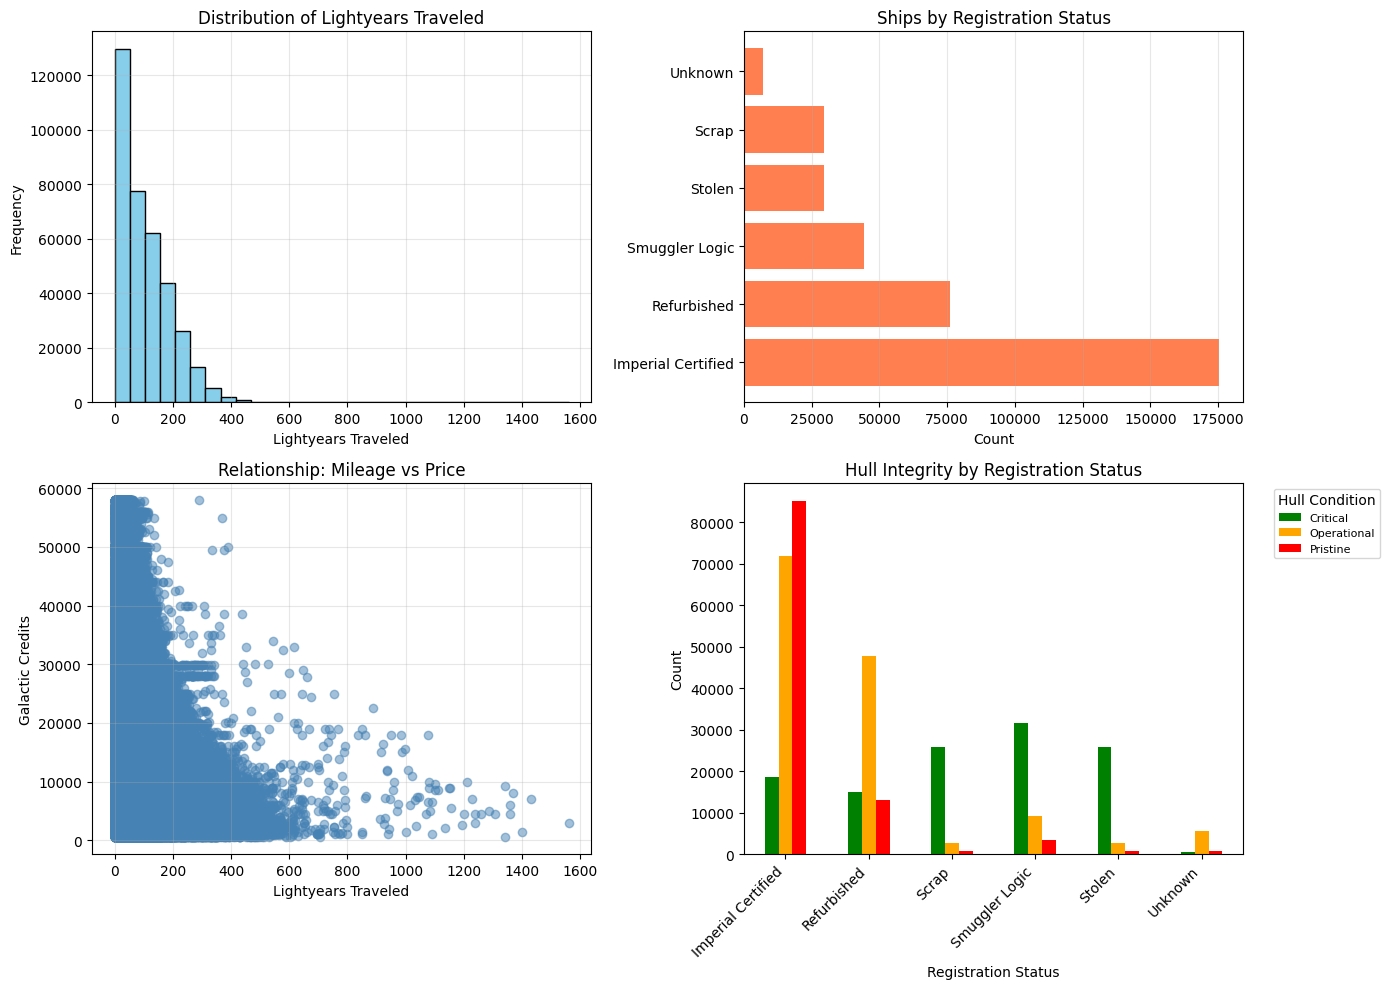

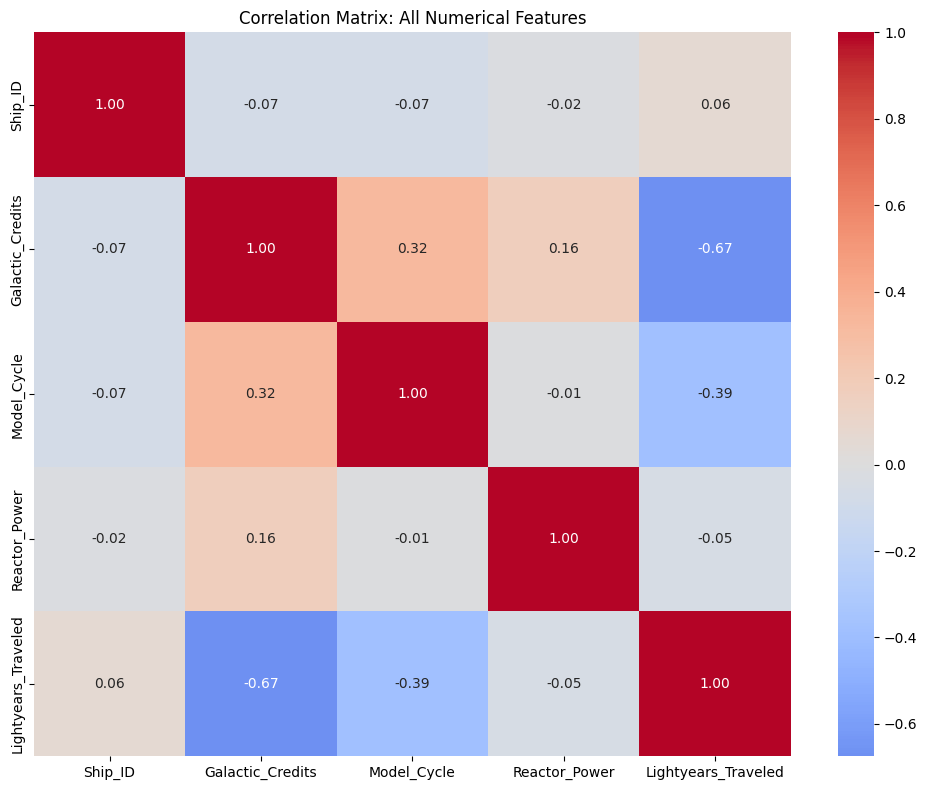

In [4]:
# Create visualizations for the new features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of Lightyears_Traveled
ax1 = axes[0, 0]
if 'Lightyears_Traveled' in df_merged.columns:
    ax1.hist(df_merged['Lightyears_Traveled'], bins=30, color='skyblue', edgecolor='black')
    ax1.set_xlabel('Lightyears Traveled')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Distribution of Lightyears Traveled')
    ax1.grid(alpha=0.3)

# 2. Registration Status Distribution
ax2 = axes[0, 1]
if 'Registration_Status' in df_merged.columns:
    status_counts = df_merged['Registration_Status'].value_counts()
    ax2.barh(status_counts.index, status_counts.values, color='coral')
    ax2.set_xlabel('Count')
    ax2.set_title('Ships by Registration Status')
    ax2.grid(alpha=0.3, axis='x')

# 3. Lightyears_Traveled vs Galactic_Credits
ax3 = axes[1, 0]
if 'Lightyears_Traveled' in df_merged.columns and 'Galactic_Credits' in df_merged.columns:
    ax3.scatter(df_merged['Lightyears_Traveled'], df_merged['Galactic_Credits'], 
                alpha=0.5, color='steelblue')
    ax3.set_xlabel('Lightyears Traveled')
    ax3.set_ylabel('Galactic Credits')
    ax3.set_title('Relationship: Mileage vs Price')
    ax3.grid(alpha=0.3)

# 4. Hull Integrity distribution by Registration Status (using count plot)
ax4 = axes[1, 1]
if 'Registration_Status' in df_merged.columns and 'Hull_Integrity' in df_merged.columns:
    cross_tab = pd.crosstab(df_merged['Registration_Status'], df_merged['Hull_Integrity'])
    cross_tab.plot(kind='bar', ax=ax4, color=['green', 'orange', 'red', 'gray'][:len(cross_tab.columns)])
    ax4.set_xlabel('Registration Status')
    ax4.set_ylabel('Count')
    ax4.set_title('Hull Integrity by Registration Status')
    ax4.legend(title='Hull Condition', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.sca(ax4)
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Additional correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
numerical_cols = df_merged.select_dtypes(include=[np.number]).columns
correlation_matrix = df_merged[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix: All Numerical Features')
plt.tight_layout()
plt.show()

**Data insights and data quality**

**Data insights**
<br>
*Does high mileage lower the price?*

Yes, in the merged data, price is `Galactic_Credits` and mileage is `Lightyears_Traveled`.
ships with higher mileage tend to be much cheaper.

*Does a Stolen status correlate with Critical hull condition?*

Yes,
Ships that are marked stolen are about 87.9% are Critical.
Non-stolen ships are about 27.6% are Critical.
So stolen ships are far more likely to have critical hull integrity than non-stolen ships.

**Data quality issues**
<br>The merged dataset contains 361,069 ships, which matches the smallest source file (ship_performance_logs_iter3.csv), so not every ship in inventory or inspections is present in performance logs.

***Missing values in the merged dataset:***
<br>Reactor_Power: 28,856 missing
<br>Propulsion_Type: 55,478 missing
<br>Model_Cycle: 7,258 missing
<br>This means some ships have incomplete inspection or inventory details even after merging.


---

## 3. Data Preparation

**Cleaning and preprocessing**

*Describe and justify how you resolve your data errors.*

We clean the merged ship dataset by dropping duplicate ship records, converting numeric columns to valid numeric types, and preserving as much data as possible while keeping the two model targets intact.

- Drop duplicate `Ship_ID` rows to avoid duplicate training examples.
- Drop rows missing essential labels or targets: `Galactic_Credits`, `Hull_Integrity`, `Lightyears_Traveled`, or `Registration_Status`.
- Impute missing numeric features with the median because these features are continuous and the median is less effected by outliers.
- Impute missing categorical features with `Unknown` so the model can still learn from the record without discarding it.

In [11]:
# Data cleaning and preprocessing

df_clean = df_merged.copy()
df_clean = df_clean.drop_duplicates(subset='Ship_ID', keep='first')


numeric_columns = ['Galactic_Credits', 'Model_Cycle', 'Reactor_Power', 'Lightyears_Traveled']
for col in numeric_columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

df_clean = df_clean.dropna(subset=['Galactic_Credits', 'Hull_Integrity', 'Lightyears_Traveled', 'Registration_Status'])

df_clean['Reactor_Power'] = df_clean['Reactor_Power'].fillna(df_clean['Reactor_Power'].median())
df_clean['Model_Cycle'] = df_clean['Model_Cycle'].fillna(df_clean['Model_Cycle'].median())
df_clean['Propulsion_Type'] = df_clean['Propulsion_Type'].fillna('Unknown')
df_clean['Ship_Class'] = df_clean['Ship_Class'].fillna('Unknown')
df_clean['Ship_Manufacturer'] = df_clean['Ship_Manufacturer'].fillna('Unknown')
df_clean['Sector'] = df_clean['Sector'].fillna('Unknown')
df_clean['Registration_Status'] = df_clean['Registration_Status'].fillna('Unknown')

df_prepared = df_clean.copy()

print('Cleaned dataset shape:', df_prepared.shape)
print('Missing values after cleaning:')
print(df_prepared.isna().sum())

print('\nTarget counts for Hull_Integrity:')
print(df_prepared['Hull_Integrity'].value_counts())
print('\nRegistration_Status counts:')
print(df_prepared['Registration_Status'].value_counts())

Cleaned dataset shape: (361069, 11)
Missing values after cleaning:
Ship_ID                0
Galactic_Credits       0
Model_Cycle            0
Ship_Manufacturer      0
Sector                 0
Hull_Integrity         0
Reactor_Power          0
Propulsion_Type        0
Ship_Class             0
Lightyears_Traveled    0
Registration_Status    0
dtype: int64

Target counts for Hull_Integrity:
Hull_Integrity
Operational    139735
Critical       117387
Pristine       103947
Name: count, dtype: int64

Registration_Status counts:
Registration_Status
Imperial Certified    175316
Refurbished            75884
Smuggler Logic         44117
Stolen                 29443
Scrap                  29391
Unknown                 6918
Name: count, dtype: int64


**Feature encoding**

*Describe how you converted your categorical columns into a format the model can use.*

We encode categorical variables into binary indicator features using `OneHotEncoder` so both regression and classification models can use them. The selected categorical columns are those expected to influence price and hull integrity.

In [9]:
# Apply feature encoding and define model feature matrices
categorical_columns = ['Ship_Manufacturer', 'Sector', 'Propulsion_Type', 'Ship_Class', 'Registration_Status']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_values = encoder.fit_transform(df_prepared[categorical_columns])
encoded_feature_names = encoder.get_feature_names_out(categorical_columns)

df_encoded = pd.DataFrame(encoded_values, columns=encoded_feature_names, index=df_prepared.index)

# Select numeric features that are already usable as-is
numeric_features = ['Lightyears_Traveled', 'Model_Cycle', 'Reactor_Power']

df_model = pd.concat([df_prepared[numeric_features], df_encoded], axis=1)

# Define regression and classification targets
X = df_model
y_reg = df_prepared['Galactic_Credits']
y_clf = df_prepared['Hull_Integrity']

print('Feature matrix shape:', X.shape)
print('Regression target shape:', y_reg.shape)
print('Classification target shape:', y_clf.shape)
print('\nExample feature columns:')
print(X.columns[:20].tolist())



Feature matrix shape: (361069, 105)
Regression target shape: (361069,)
Classification target shape: (361069,)

Example feature columns:
['Lightyears_Traveled', 'Model_Cycle', 'Reactor_Power', 'Ship_Manufacturer_Bayerische Motoren Wormhole', 'Ship_Manufacturer_Corelian Engineering', 'Ship_Manufacturer_Corellian Eng.', 'Ship_Manufacturer_Corellian Engineering', 'Ship_Manufacturer_Corellian Engineering Corp', 'Ship_Manufacturer_Droid Works', 'Ship_Manufacturer_GALACTIC MOTORS', 'Ship_Manufacturer_Galactic Motors', 'Ship_Manufacturer_Galactic Motors ', 'Ship_Manufacturer_Galactic Motrs', 'Ship_Manufacturer_Galactic_Motors', 'Ship_Manufacturer_General Mining Corp', 'Ship_Manufacturer_Hondo Systems', 'Ship_Manufacturer_Ind. Shipwrights', 'Ship_Manufacturer_Independent', 'Ship_Manufacturer_Independent Shipwright', 'Ship_Manufacturer_Independent Shipwrights']


---

## 4. Modeling: Task A

**Regression setup**

*Set up a [Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) model to predict `Galactic_Credits`. Make sure to split your data into training and testing sets.*

In [3]:
# CODE CELL: Train-Test split & train the Linear Regression model

**Testing and performance (Regression)**

*Calculate the MAE, RMSE and R2 score. Create a plot showing Actual vs. Predicted prices to visually verify model performance.*

In [4]:
# CODE CELL: Evaluate the rgression model and plot Actual vs Predicted

---

## 5. Modeling: Task B

**Classification setup**

*Set up a [Decision Tree Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) to predict `Hull_Integrity`. Split the data into training and testing sets.*

In [7]:
# CODE CELL: Train-Test split & train the Decision Tree model.

**Testing and performance (classification)**

*Calculate the Accuracy and plot a confusion matrix. Explain what the matrix tells you about the predictions.*

In [6]:
# CODE CELL: Evaluate your classification model (check ou tthe metrics, include a confusion matrix)

---

## 6. Evaluation

**Assessment against success criteria** 

*Compare your models to the baselines:*
* *Are thr scores of this regression model better than Iteration 1? Why?*
* *Are the scores of the decision tree better than your manual rules from Iteration 2? Why?*

**Key findings and limitations**

*What are the final conclusions? Should Nebula Brokerage deploy these models? What are the remaining limitations?*

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset.

---

## 7. Personal Contribution

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Student name 1 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 2 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 3 | *Contribution description* | *Personal lessons learned this iteration* |